# **Comparative Analysis of Literary Translations in the Odyssey: Zipf's Law in Depth**

This is a comparative Zipf's Law analysis of six translations spanning roughly the last century: 1919–2018. 

## **Road Map**

### I. Libraries, files, and paths

### II. Zipf's Law Analysis

1. All-in, straightforward model  
    a) TTR Computation  
    b) Shapiro-Wilk test to check for normality  
    c) One-wat ANOVA for overall differences  
    d) Pairwise t-test using Bonferroni coprrection  
    c) Meassuring effect size ussing Cohen's d  

2. Adaptive models  
    a) Mixed-Effects model: author fixed effect / book as random effect  
    b) Standardized TTR:   
    c) Moving-average TTR: translation as temporal change  

3. Supplement models  
    a) Lexical Density   
    b) Diachronic analysis  
    c) Semantic fields:  

### IV. Discussing Results
    

## **I. Libraries, files, and paths**

In [1]:
#### Other libraries
import sys
import os

import ast
from collections import Counter

import re
import nltk

In [2]:
#### Pandas set-up
import numpy as np
import pandas as pd

In [3]:
#### Visualization
sys.path.append('/Users/debr/English-Homer') 
import matplotlib.pyplot as plt
import seaborn as sns
import bard_visualization as viz # My Vizualization library

Bard viz is on the stage!


In [4]:
# Import my functions
sys.path.append('/Users/debr/English-Homer/functions') 
import e_nlp as e

e enters! »----> use e.<function>

e.g., for pipeline:
		 nlp = e.NLPPipeline(language="english")

Stopwords customized:
  Added: {'four', 'one', 'ten', 'six', 'nine', 'eight', 'three', 'seven', "'", 'two', "'and", 'five', 'n'}
  Removed: {''}
  Total stopwords: 211
Punctuation customized:
  Keeping: {'', '-'}
  Additional removals: {'—', '“', '”', '\\', '’', '‘', '…', '-'}
  Punctuation to be removed: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~—‘’“”…


[nltk_data] Downloading package punkt_tab to /Users/debr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [5]:
#### Cell display options
pd.set_option("display.max_rows", 2000)  # Increase row display
pd.set_option("display.max_colwidth", 200)  # Prevent truncation of long values
pd.set_option("display.precision", 2)  # Display numbers with two decimal places
pd.set_option("display.float_format", "{:.2f}".format)  # Format float numbers
pd.set_option("display.max_columns", None)  # Show all columns
#pd.set_option("display.expand_frame_repr", False)  # Prevent wrapping in DataFrames
pd.set_option("display.width", 1000)  # Prevent wrapping in DataFrames
pd.set_option("colheader_justify", "left")

In [6]:
#### File management
# TO UPDATE
nb_id = "Zipf_Six_Modern"
translators = ["AT_Murray", "Fitzgerald", "Lattimore", "Fagles", "Wilson", "Green"]

# Paths
output_path = f"/Users/debr/English-Homer/{nb_id}/"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

output_path_plots = f"{output_path}/{nb_id}_plots/"
os.makedirs(os.path.dirname(output_path_plots), exist_ok=True)

In [7]:
# Daframe with all the translators
dfs = []

for odyssey in translators:
    filepath = f"/Users/debr/odysseys_en/dataframed/Odyssey_{odyssey}_DataFrame.csv"
    temp_df = pd.read_csv(filepath)  
    dfs.append(temp_df)  # Append it to the list

df = pd.concat(dfs, axis=0, ignore_index=True)

df["text"] = df["text"].apply(ast.literal_eval)
df["tokens"] = df["tokens"].apply(ast.literal_eval)
df['translator'] = pd.Categorical(df['author'])
df["book_num"] = pd.Categorical(df["book_num"])
df = df[['translator', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens']]
e.check_df(df)

Oh, yeah! No missing values here!

* df columns: Index(['translator', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens'], dtype='object') 

* Shape: (144, 6) 

* Total memory: 3.490719


#### 2. **The translators**

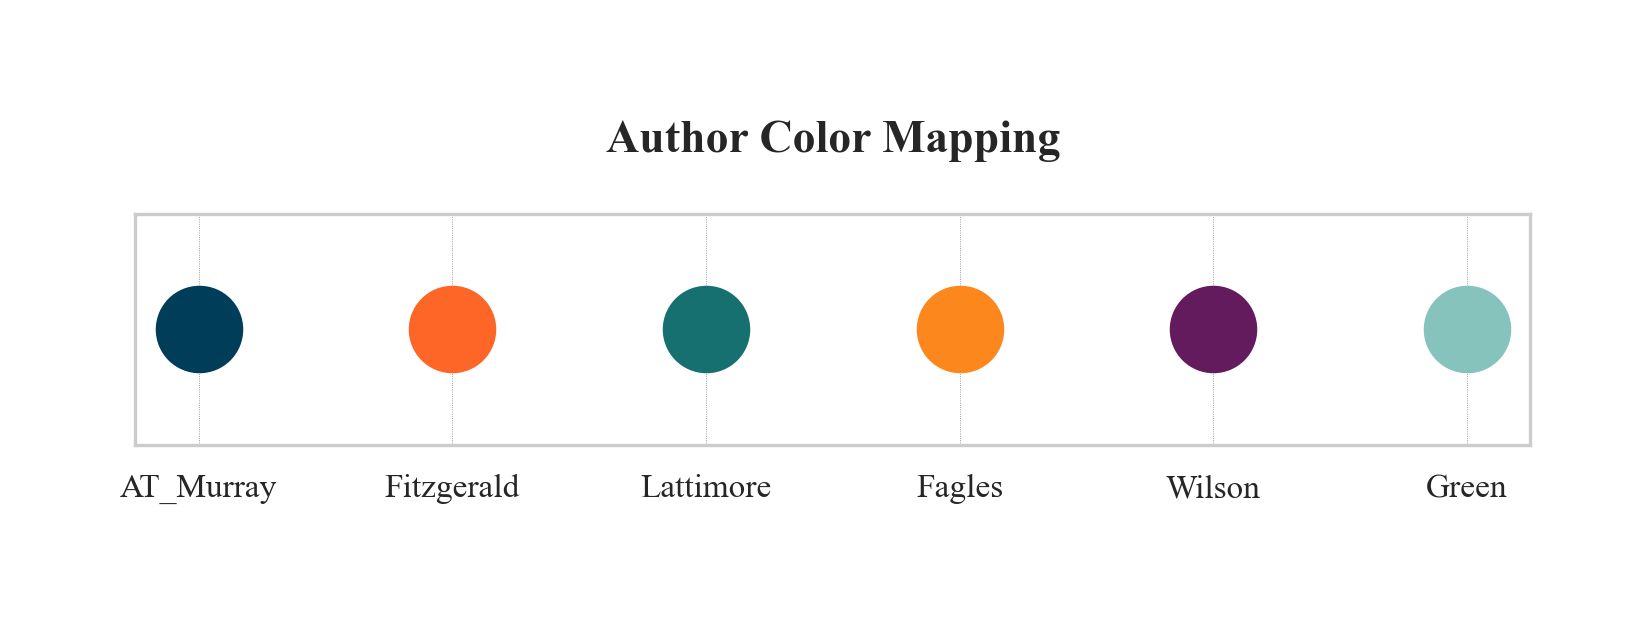

In [8]:
# Color mapping authors
palette = {author: color for author, 
           color in zip(translators, viz.color_palette.values())}

plt.figure(figsize=(6, 1))

for i, (author, color) in enumerate(palette.items()):
    plt.scatter(i, 0, color=color, s=400)

plt.xticks(range(len(palette)), palette.keys(), fontsize=8)
plt.yticks([])
plt.title("Author Color Mapping", fontsize=11)
plt.savefig(f"{output_path_plots}author_color_mapping-{nb_id}.png")
plt.show()

________________________________
## **II. Zipf’s Law Analysis**

### **What and why:** 

Zipf’s Law states that in a large text corpus, the frequency of a word is inversely proportional to its rank in the frequency table. This metric is relevant in comparing translations because it reveals how each translator balances **common vs. rare words**, shedding light on **lexical richness and stylistic choices**. This experiment provides empirical insight into whether a translator’s lexical distribution align with universal linguistic principles.


### **Implications for Translation Studies**

**a) natural linguistic flow:** Strong Zipfian adherence suggests that translators maintain natural language patterns, balancing high-frequency function words with low-frequency content words.  

**b.1) Poetic stylization:** Deviations may indicate differences in lexical richness, syntactic choices, or stylistic adaptation in translation.  
**b.2) Philological fidelity:** 'Stylistic' shifts can also point out to genre requirements that, in the case of epic oral poetry, demand disticnt repetitive and formulaic patterns, epithets, etc.



### **Implementation** 

Zipf’s Law states that in any natural language corpus, *the frequency of a word is inversely proportional to its rank:* 


$$ f \propto \frac{1}{r} $$

Where:
* f = frequency of the word
* r = rank of the word (1st most frequent, 2nd most frequent, etc.)

Procedure:
1. Compute word frequencies for each translation.  
2. Rank words from most to least frequent.  
3. Plot word frequency vs. rank on a log-log scale. 


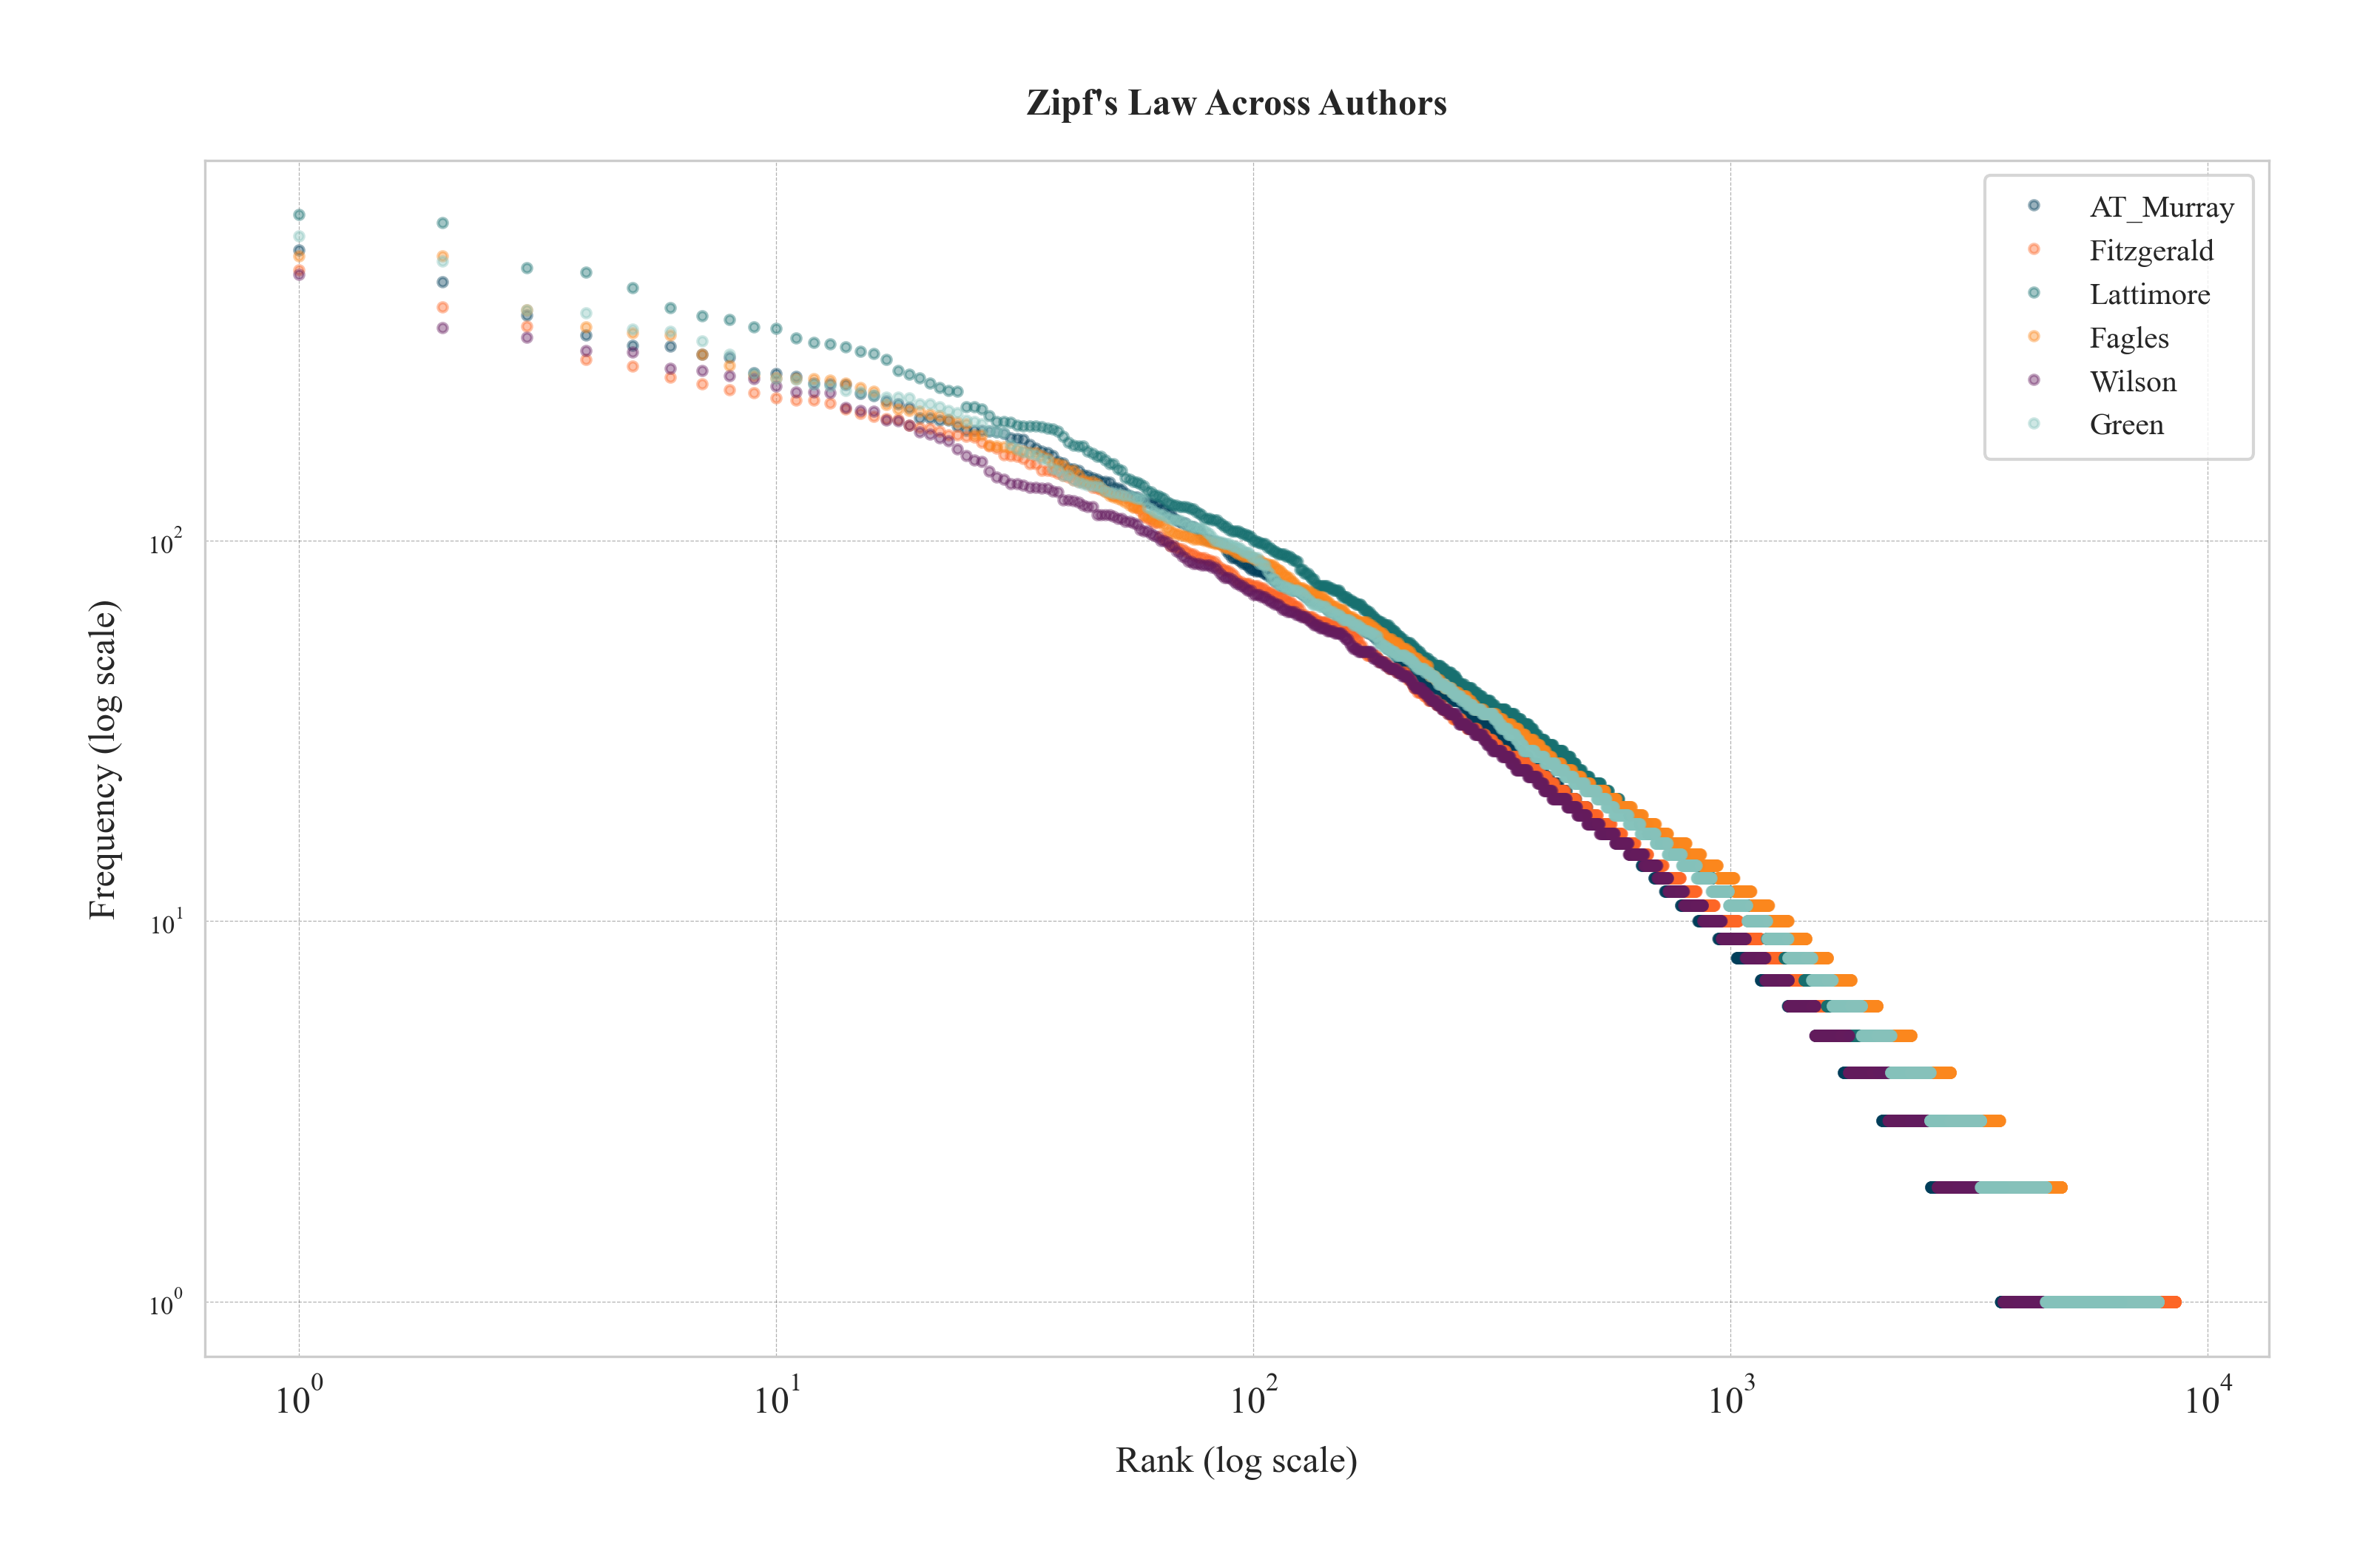

In [9]:
# Step 1: Flatten tokens and count word frequencies for each translator
freq_dict = {
    translator: Counter(
        token for tokens in df[df["translator"] == translator]["tokens"] for token in tokens
    )
    for translator in translators
}

# Step 2: Convert word frequencies into sorted DataFrames with rank
df_word_freq_rank_dict = {
    translator: pd.DataFrame(freq.items(), columns=["word", "frequency"])
    .sort_values(by="frequency", ascending=False)
    .assign(rank=lambda df_: df_["frequency"].rank(method="first", ascending=False))
    for translator, freq in freq_dict.items()
}

# Step 3: Zipf's Law Plot
def plot_zipfs_law(df_word_freq_rank_dict):

    for author, df_zipf in df_word_freq_rank_dict.items():
        plt.loglog(df_zipf["rank"], df_zipf["frequency"], label=author, marker=".", linestyle="None", alpha=0.4)

    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.title("Zipf's Law Across Authors")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.3, alpha=0.3)
    plt.show()

# Call the plotting function
plot_zipfs_law(df_word_freq_rank_dict)

In [10]:

# Create a function to calculate Zipf's law for each book and author
def calculate_zipf(row):
    # Tokenize the 'text' column (assuming words are space-separated)
    words = row['tokens']  # Use the list of tokens directly
    
    # Calculate frequency of each word
    word_freq = pd.Series(words).value_counts()
    
    # Rank words based on frequency (most frequent gets rank 1)
    word_freq = word_freq.sort_values(ascending=False)
    
    # Rank is the index of the sorted values (this is the Zipf rank)
    ranks = np.log(np.arange(1, len(word_freq) + 1))  # Zipf's Law ranks, log scale
    
    # Compute Zipf's law score: Rank vs. Frequency relationship
    log_freq = np.log(word_freq.values + 1)  # Log-transform frequency (to avoid log(0))
    log_rank = np.log(ranks + 1)  # Log-transform rank (to avoid log(0))
    
    # You can use linear regression or other methods to compute the Zipf slope, or just save the rank values.
    # For simplicity, I will return the Zipf rank.
    
    return log_rank, log_freq  # You can modify what you want to return (rank, frequency, slope, etc.)

# Apply this function to each row in the df
df['zipf'] = df.apply(calculate_zipf, axis=1)

# The result will be a tuple, you may want to expand it into two separate columns (for rank and frequency):
df[['zipf_rank', 'zipf_freq']] = pd.DataFrame(df['zipf'].tolist(), index=df.index)

# If you want to combine both values into a single "zipf" column, you can do that as well:
df['zipf'] = df['zipf_rank'] - df['zipf_freq']  # or any other combination you need

# View the result
print(df[['zipf', 'zipf_rank', 'zipf_freq']].head())

  zipf                                                                                                                                                                                                     zipf_rank                                                                                                                                                                                                zipf_freq                                                                                                                                                                                               
0  [-3.258096538021482, -2.4691432394149464, -2.2031626677914247, -2.0746972929744962, -1.9312369189753404, -1.8636997266971136, -1.8099539396231767, -1.647840459330745, -1.5457670872182097, -1.51334...  [0.0, 0.5265890341390446, 0.7412763113750154, 0.8697416861919439, 0.959134838920824, 1.026672031199051, 1.0804178182729878, 1.1247482629090362, 1.1622831138840004, 1.1947055233182955, 1.22315

In [16]:
e.check_df(df)

Oh, yeah! No missing values here!

* df columns: Index(['translator', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens', 'zipf', 'zipf_rank', 'zipf_freq'], dtype='object') 

* Shape: (144, 9) 

* Total memory: 7.474911


In [12]:
len(df['zipf'][0])

881

In [14]:
len(df['tokens'][0])

1800

One-Way ANOVA (Single Test for All Translators)

The ANOVA test is used when you want to compare the means of more than two groups—in this case, the slopes of the different translators. This will tell you if there are any significant differences between the slopes across all translators.
